In [ ]:
from google.colab import drive
#mounting drive here

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#importing required libs

import os
import zipfile

import pathlib
import os
import glob as gb

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model

from tensorflow.keras import metrics
from tensorflow.keras.metrics import Precision, Recall
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau



In [ ]:
# Defining the path to the zip file and the extraction directory
zip_File = "/content/drive/MyDrive/Dataset_plant.zip"
extract_dir_destination = "/content"

#To Check if the zip file exists
if os.path.exists(zip_File):
    try:
        # Create a ZipFile object
        with zipfile.ZipFile(zip_File, 'r') as zip_ref:
            # Extract all contents to the specified directory
            zip_ref.extractall(extract_dir_destination)
        print(f"Successfully extracted '{zip_File}' to '{extract_dir_destination}'")
    except zipfile.BadZipFile:
        print(f"Error: '{zip_File}' is not a valid zip file.")
    except Exception as e:
        print(f"An error occurred: {e}")
else:
    print(f"Error: '{zip_File}' does not exist.")

Successfully extracted '/content/drive/MyDrive/Dataset_plant.zip' to '/content'


In [ ]:
from sklearn.model_selection import train_test_split
import os
import shutil

# Path to your current validation data
valid_dir = "/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid"

# Getting a list of the subfolders (i.e., classes)
classes = os.listdir(valid_dir)

# Create new directories for validation and test
new_valid_dir = "/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/split_valid_data"
new_test_dir = "/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/split_test_data"

# Create subfolders in new directories for each class
for cls in classes:
    os.makedirs(os.path.join(new_valid_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(new_test_dir, cls), exist_ok=True)

# Loop over each class to move 50% of validation images into the test directory
for cls in classes:
    class_folder = os.path.join(valid_dir, cls)
    images = os.listdir(class_folder)

    # Split the images into two sets (50% validation, 50% test)
    valid_images, test_images = train_test_split(images, test_size=0.5, random_state=42)

    # Move images to the new directories
    for image in valid_images:
        shutil.move(os.path.join(class_folder, image), os.path.join(new_valid_dir, cls, image))
    for image in test_images:
        shutil.move(os.path.join(class_folder, image), os.path.join(new_test_dir, cls, image))

print("Data split into validation and test directories.")


Data split into validation and test directories.


In [ ]:
# Directories
train_dir = "/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"
valid_dir = "/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/split_valid_data"
test_dir = "/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/split_test_data"

In [ ]:
# Image size and batch size
size = 224
batch_size = 64

In [ ]:
# Data Augmentation, Image Preprocessing, Data Generators for Training, Validation, and Testing

In [ ]:
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1/255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=False,
    width_shift_range=0.1,
    height_shift_range=0.1,
)

valid_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1/255)

test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1/255)

In [ ]:
 train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(size, size),
    batch_size=batch_size,
    subset='training',
    class_mode='categorical',
    shuffle=True
)


valid_generator = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=(size, size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)


Found 70295 images belonging to 38 classes.
Found 8777 images belonging to 38 classes.


In [ ]:
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(size, size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 8795 images belonging to 38 classes.


In [ ]:
# To see labels
train_generator.class_indices

{'Apple___Apple_scab': 0,
 'Apple___Black_rot': 1,
 'Apple___Cedar_apple_rust': 2,
 'Apple___healthy': 3,
 'Blueberry___healthy': 4,
 'Cherry_(including_sour)___Powdery_mildew': 5,
 'Cherry_(including_sour)___healthy': 6,
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7,
 'Corn_(maize)___Common_rust_': 8,
 'Corn_(maize)___Northern_Leaf_Blight': 9,
 'Corn_(maize)___healthy': 10,
 'Grape___Black_rot': 11,
 'Grape___Esca_(Black_Measles)': 12,
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13,
 'Grape___healthy': 14,
 'Orange___Haunglongbing_(Citrus_greening)': 15,
 'Peach___Bacterial_spot': 16,
 'Peach___healthy': 17,
 'Pepper,_bell___Bacterial_spot': 18,
 'Pepper,_bell___healthy': 19,
 'Potato___Early_blight': 20,
 'Potato___Late_blight': 21,
 'Potato___healthy': 22,
 'Raspberry___healthy': 23,
 'Soybean___healthy': 24,
 'Squash___Powdery_mildew': 25,
 'Strawberry___Leaf_scorch': 26,
 'Strawberry___healthy': 27,
 'Tomato___Bacterial_spot': 28,
 'Tomato___Early_blight': 29,
 'Toma

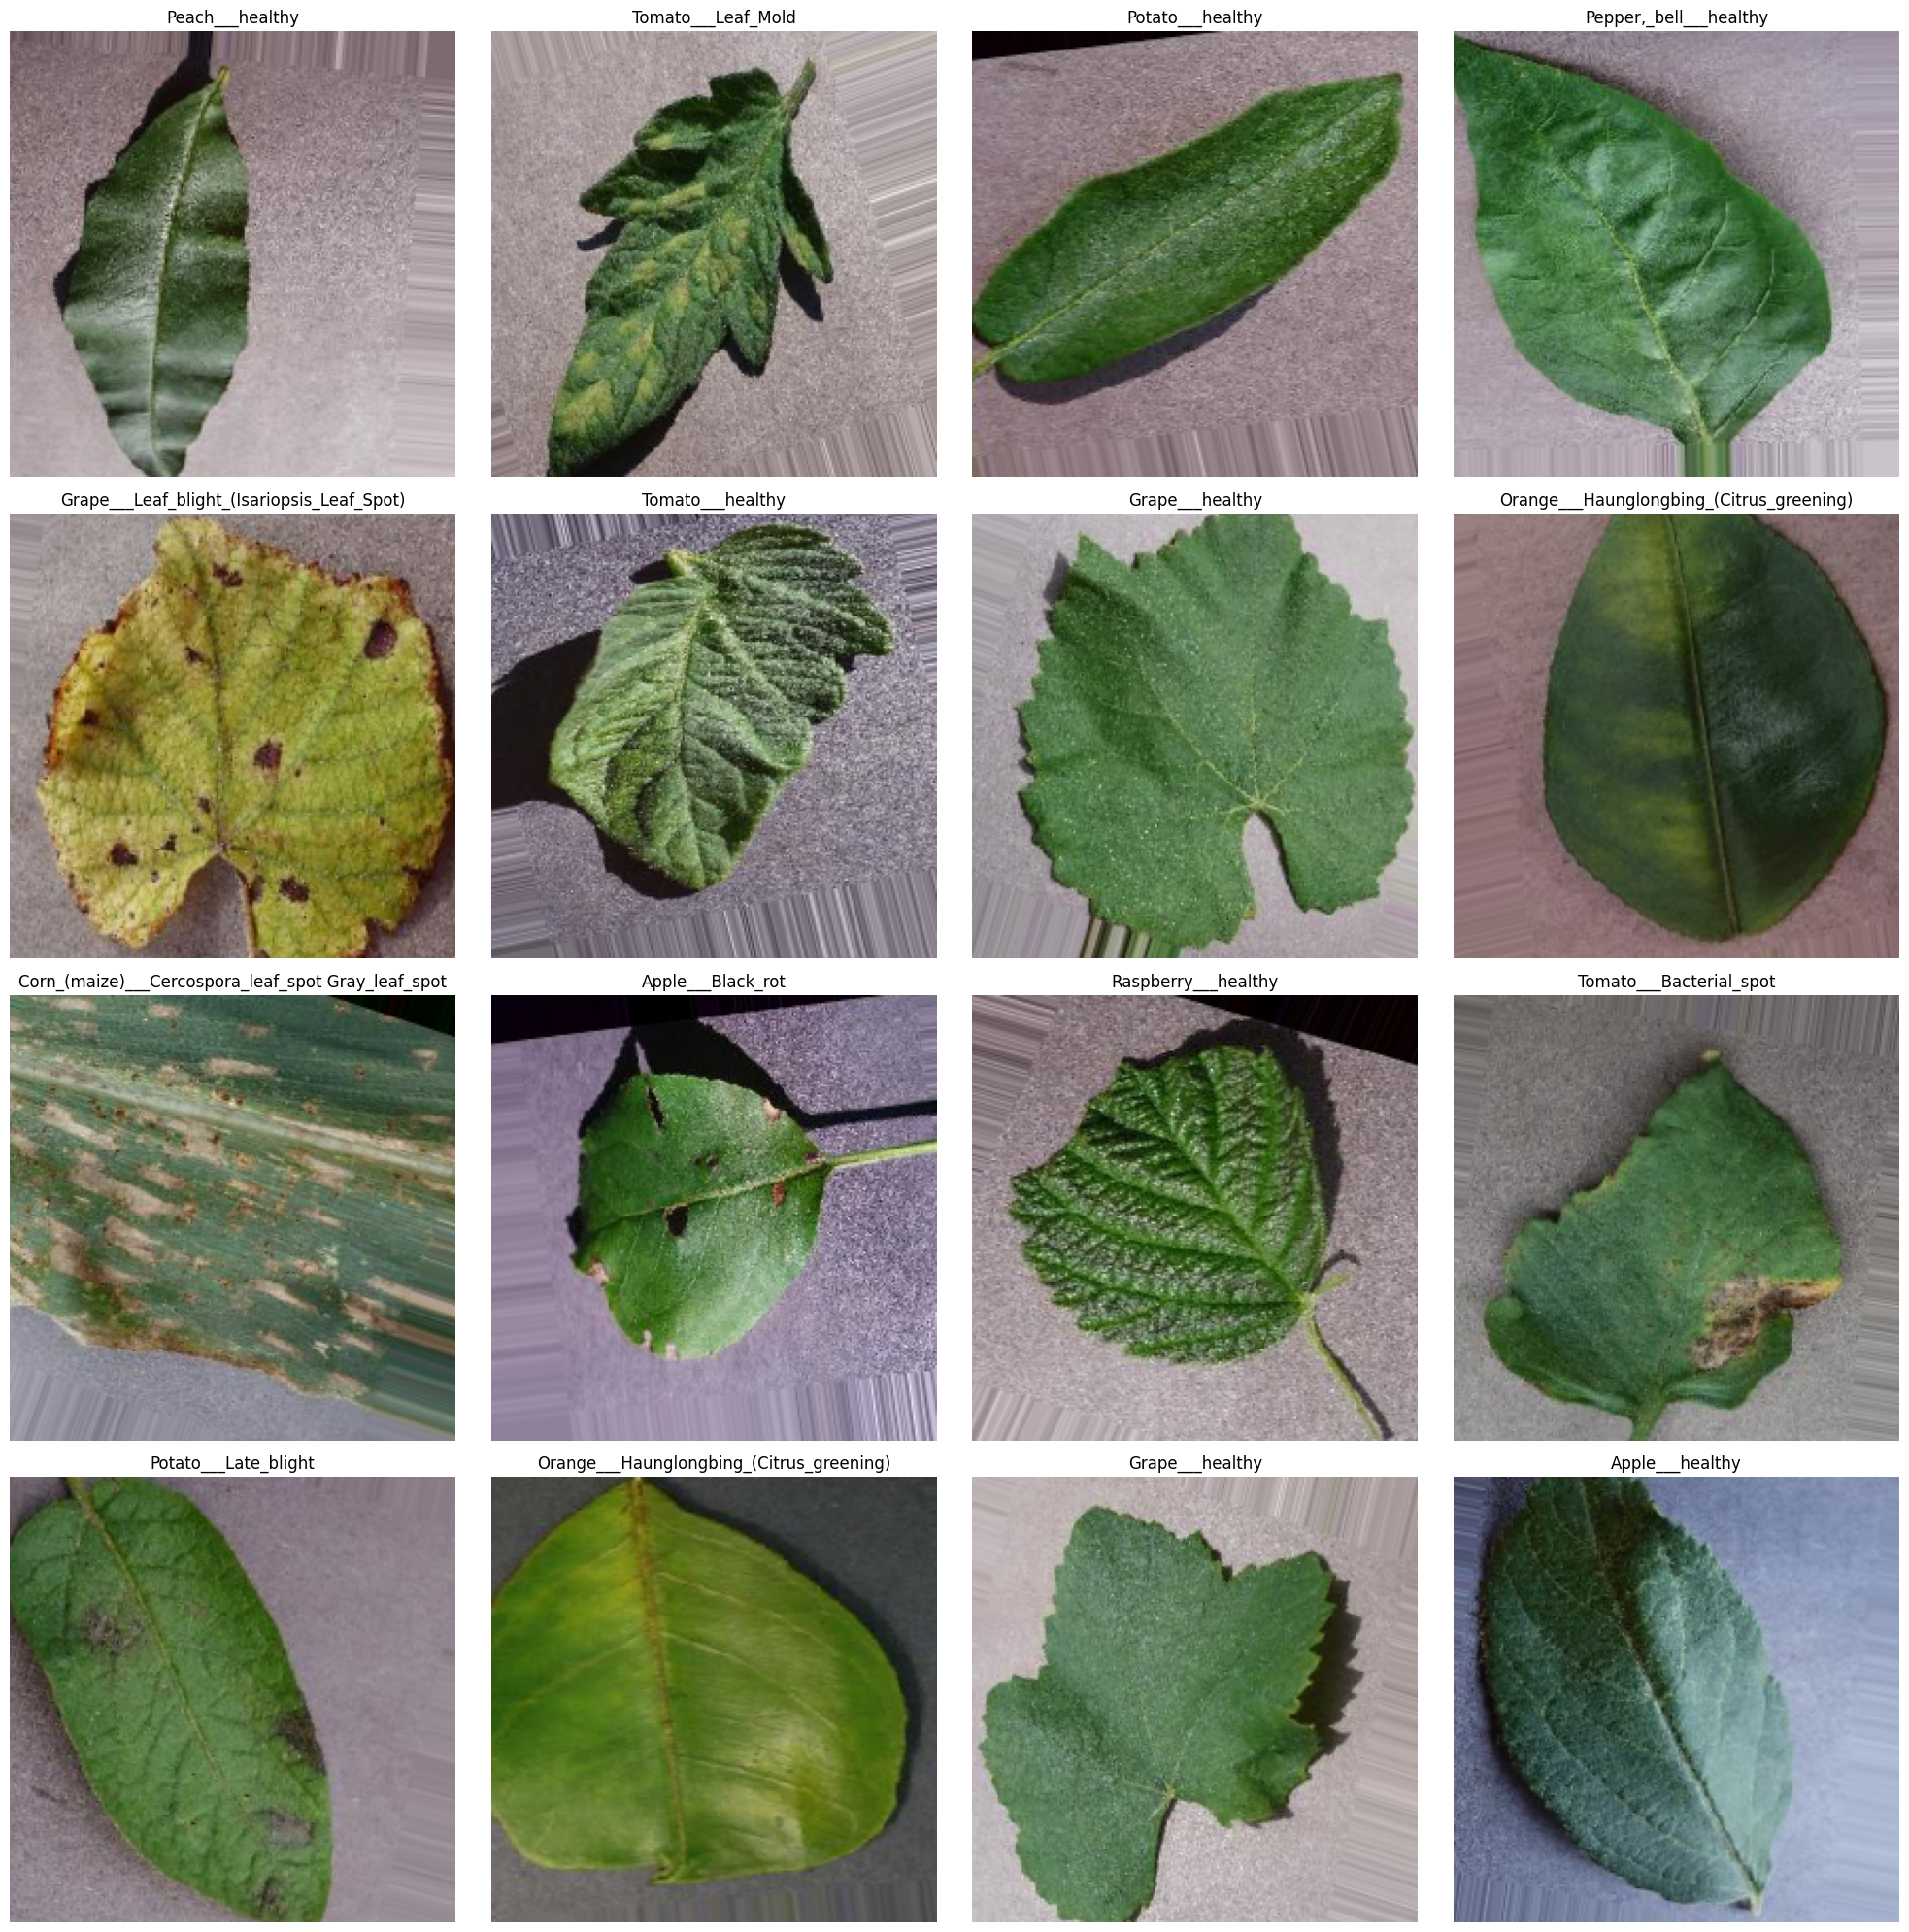

In [ ]:
# Let's display some images from training set
classes = list(train_generator.class_indices.keys())
plt.figure(figsize=(20, 20))

for X_batch, y_batch in train_generator:
    for i in range(16):  # display first 16 images
        plt.subplot(4, 4, i + 1)
        plt.imshow(X_batch[i])
        plt.title(classes[np.argmax(y_batch[i])])  # more readable
        plt.axis('off')  # hide axis
    plt.tight_layout()
    plt.show()
    break  # display only one batch


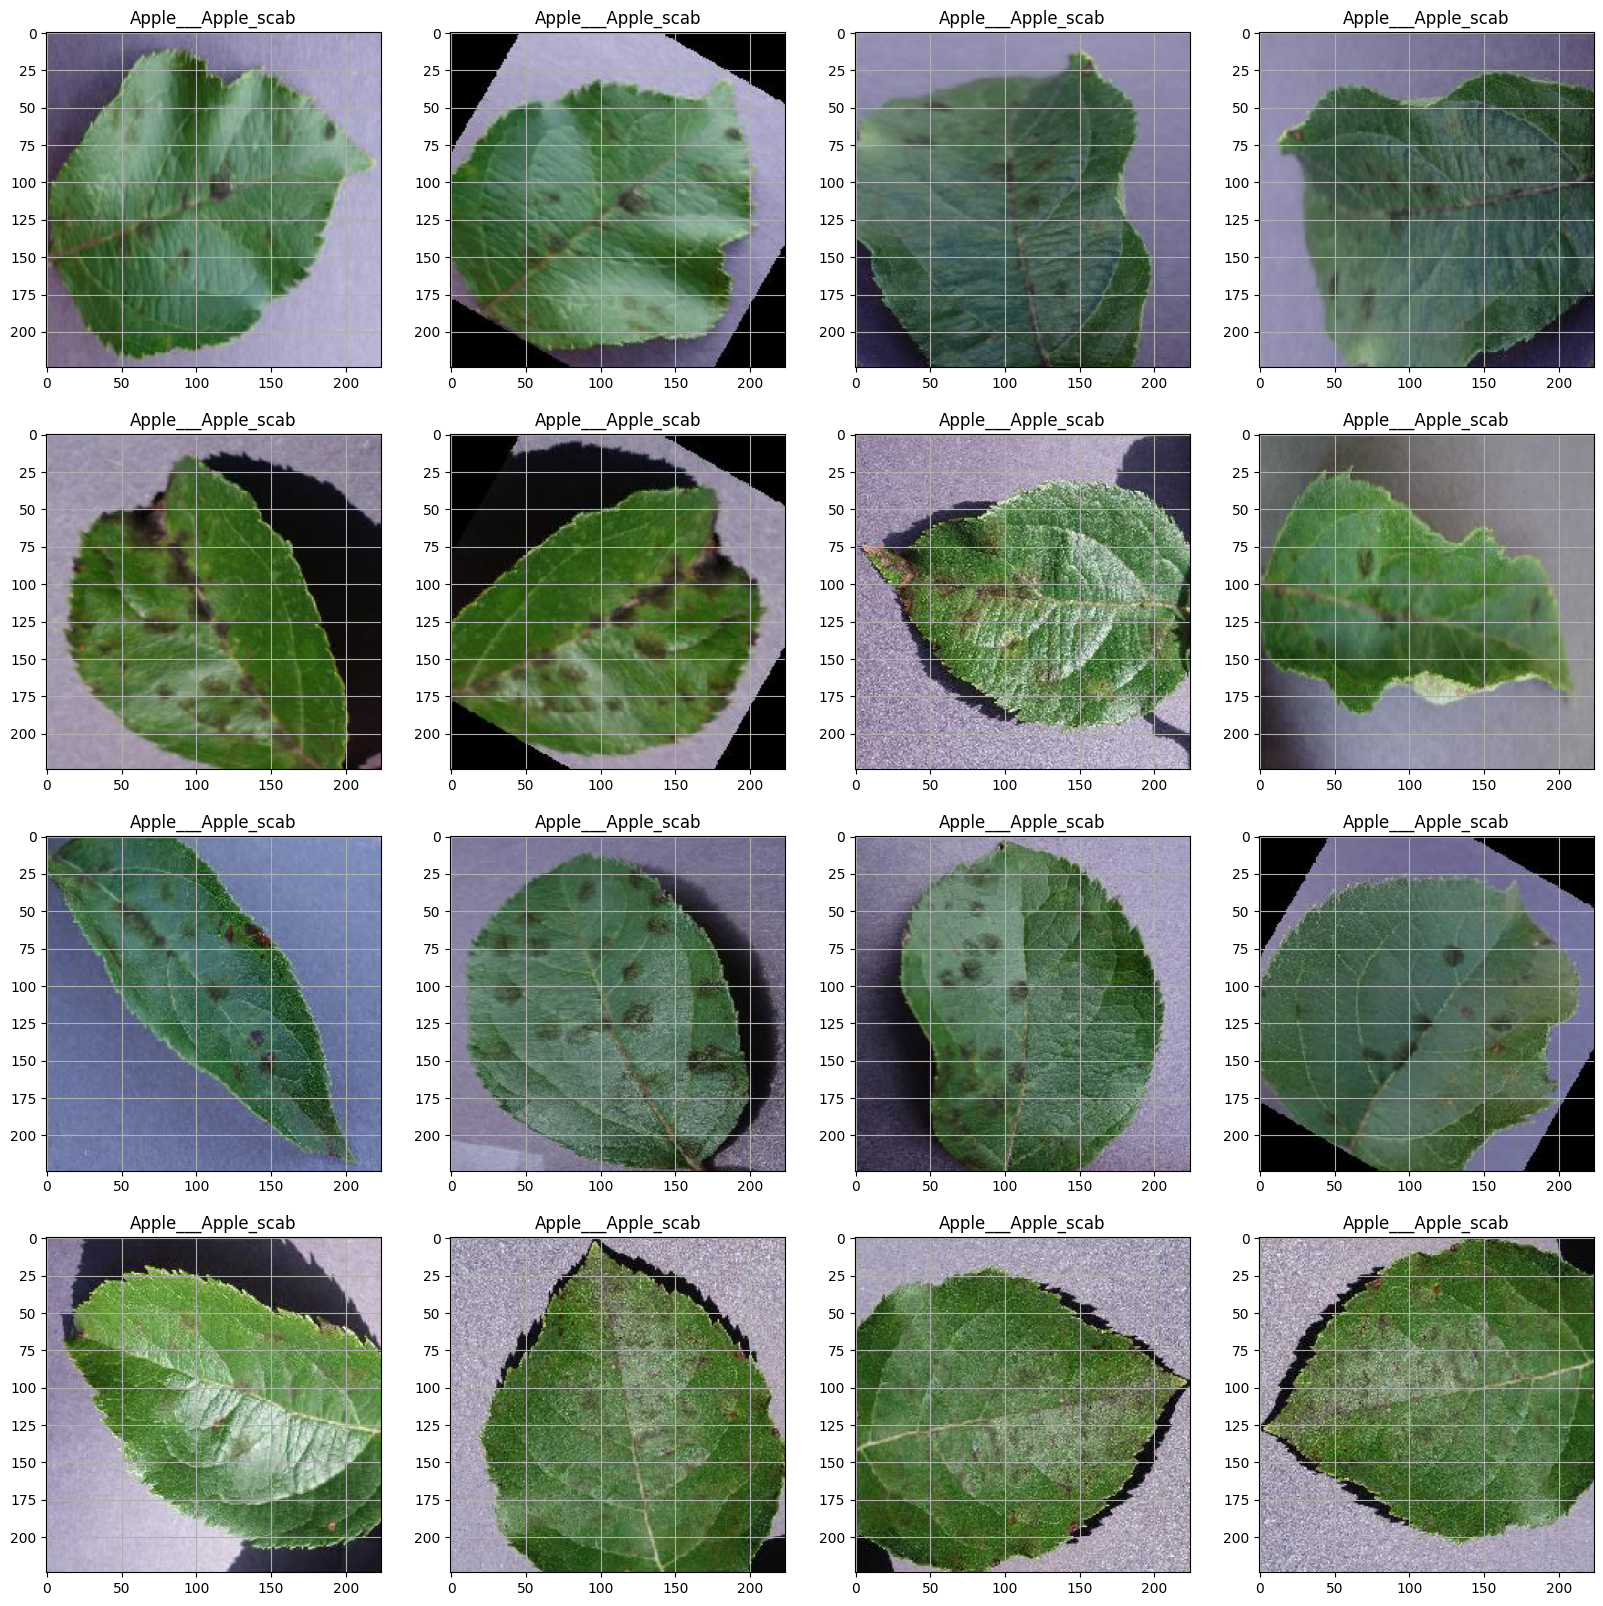

In [ ]:
#let's display some images from validation set

classes=list(valid_generator.class_indices.keys())
plt.figure(figsize=(20,20))
for X_batch, y_batch in valid_generator:
    # create a grid of 3x3 images
    for i in range(0,16):
        plt.subplot(4,4,i+1)
        plt.imshow(X_batch[i])
        plt.title(classes[np.where(y_batch[i]==1)[0][0]])   # when y is categorical
        #plt.title(classes[int(y_batch[i])])   # when y is binary or sparse
        plt.grid(None)
    # show the plot
    plt.show()
    break    #to stop the loop after displaying one batch of images from the training set


In [ ]:
# Model definition

In [ ]:
model = keras.models.Sequential()

# First convolutional block
model.add(keras.layers.Conv2D(filters=32, kernel_size=7, strides=1,
                padding="same", activation="relu", name="Conv1", input_shape=(224, 224, 3)))
model.add(keras.layers.MaxPool2D(pool_size=2, name="Pool1"))

# Second convolutional block
model.add(keras.layers.Conv2D(filters=64, kernel_size=5, strides=1,
                padding="same", activation="relu", name="Conv2"))
model.add(keras.layers.MaxPool2D(pool_size=2, name="Pool2"))

# Third and fourth convolutional blocks
model.add(keras.layers.Conv2D(filters=128, kernel_size=3, strides=1,
                padding="same", activation="relu", name="Conv3"))
model.add(keras.layers.Conv2D(filters=256, kernel_size=3, strides=1,
                padding="same", activation="relu", name="Conv4"))
model.add(keras.layers.MaxPool2D(pool_size=2, name="Pool3"))

# Flatten the feature maps before passing to fully connected layers
model.add(keras.layers.Flatten(name="Flatten1"))

# First dense layer
model.add(keras.layers.Dense(128, activation="relu", name="Dense1"))
model.add(keras.layers.Dropout(0.5))  # Dropout for regularization

# Second dense layer
model.add(keras.layers.Dense(64, activation="relu", name="Dense2"))
model.add(keras.layers.Dropout(0.5))  # Dropout for regularization

# Output layer for multi-class classification (38 classes)
model.add(keras.layers.Dense(38, activation="softmax", name="Output"))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# The model’s summary() method displays all the model’s layers
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv1 (Conv2D)                  │ (None, 224, 224, 32)   │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool1 (MaxPooling2D)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2 (Conv2D)                  │ (None, 112, 112, 64)   │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool2 (MaxPooling2D)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv3 (Conv2D)                  │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv4 (Conv2D)                  │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool3 (MaxPooling2D)            │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten1 (Flatten)              │ (None, 200704)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense1 (Dense)                  │ (None, 128)            │    25,690,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense2 (Dense)                  │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 38)             │         2,470 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,125,990 (99.66 MB)

 Trainable params: 26,125,990 (99.66 MB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
#Compiling the model and finding metrics

model.compile(
    loss='categorical_crossentropy',
    optimizer='Adam',
    metrics=[
        'accuracy',
       Precision(name='precision'),
        Recall(name='recall')
     ]
)

In [ ]:
#callbacks
early_stopping = EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

model_checkpoint = ModelCheckpoint(
    'best_model.keras', monitor='val_loss', save_best_only=True, verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.1, patience=5, min_lr=0.000001, verbose=1
)

callbacks = [early_stopping, model_checkpoint, reduce_lr]

In [ ]:
#Train the model now

In [ ]:
# Final training
history = model.fit(
    train_generator,
    epochs=13,
    validation_data=valid_generator,
    callbacks=callbacks
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/13
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 0s 882ms/step - accuracy: 0.0603 - loss: 3.5083 - precision: 0.6673 - recall: 0.0103
Epoch 1: val_loss improved from inf to 2.69631, saving model to best_model.keras
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 1022s 910ms/step - accuracy: 0.0603 - loss: 3.5082 - precision: 0.6673 - recall: 0.0103 - val_accuracy: 0.2331 - val_loss: 2.6963 - val_precision: 0.9449 - val_recall: 0.0273 - learning_rate: 0.0010
Epoch 2/13
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 0s 860ms/step - accuracy: 0.2104 - loss: 2.7211 - precision: 0.6786 - recall: 0.0476
Epoch 2: val_loss improved from 2.69631 to 1.80281, saving model to best_model.keras
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 966s 879ms/step - accuracy: 0.2104 - loss: 2.7209 - precision: 0.6786 - recall: 0.0476 - val_accuracy: 0.4494 - val_loss: 1.8028 - val_precision: 0.8851 - val_recall: 0.1588 - learning_rate: 0.0010
Epoch 3/13
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 0s 884ms/step - accuracy: 0.3568 - loss: 2.1127 - precision: 0.6873 - recall: 0

In [1]:
# def plot_training_history(history):
#     metrics = ['accuracy', 'loss', 'precision', 'recall']
#     plt.figure(figsize=(16, 12))

#     for i, metric in enumerate(metrics):
#         plt.subplot(2, 2, i+1)
#         plt.plot(history.history[metric], label=f'Training {metric}')
#         plt.plot(history.history[f'val_{metric}'], label=f'Validation {metric}')
#         plt.title(f'Training vs Validation {metric.capitalize()}')
#         plt.xlabel('Epochs')
#         plt.ylabel(metric.capitalize())
#         plt.legend()
#         plt.grid(True)

#     plt.tight_layout()
#     plt.show()

# # Call the function after training
# plot_training_history(history)


In [ ]:
#CONFUSION MATRIX

138/138 ━━━━━━━━━━━━━━━━━━━━ 31s 219ms/step


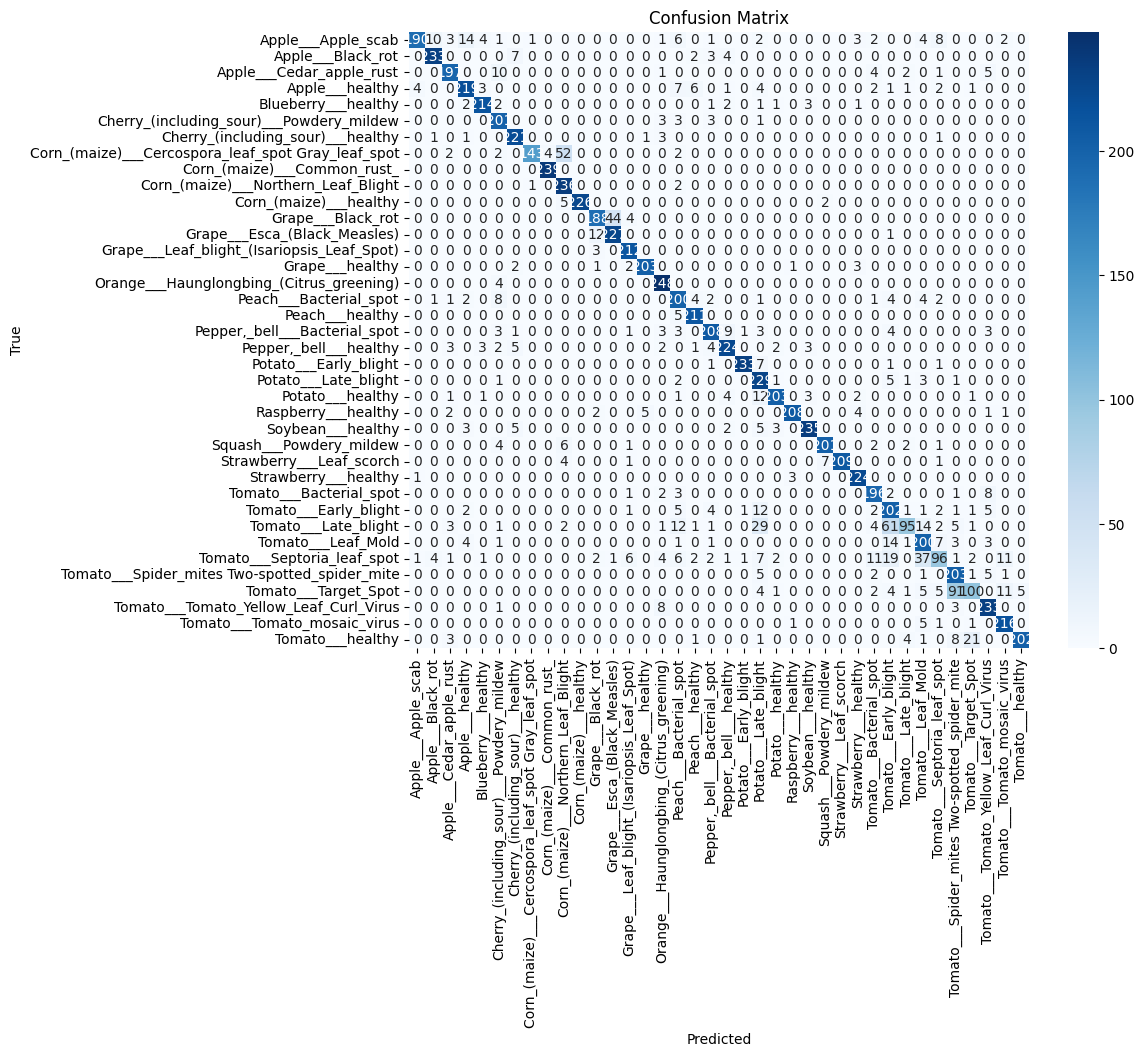

In [ ]:
# Get the true labels and predicted labels
y_true = test_generator.classes
y_pred = np.argmax(model.predict(test_generator), axis=1)

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [ ]:
#CLASSIFICATION REPORT

report = classification_report(y_true, y_pred, target_names=test_generator.class_indices.keys())
print(report)


                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.97      0.75      0.85       252
                                 Apple___Black_rot       0.94      0.94      0.94       249
                          Apple___Cedar_apple_rust       0.91      0.90      0.90       220
                                   Apple___healthy       0.89      0.87      0.88       251
                               Blueberry___healthy       0.95      0.94      0.94       227
          Cherry_(including_sour)___Powdery_mildew       0.83      0.95      0.89       211
                 Cherry_(including_sour)___healthy       0.92      0.97      0.94       228
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.99      0.70      0.82       205
                       Corn_(maize)___Common_rust_       0.98      1.00      0.99       239
               Corn_(maize)___Northern_Leaf_Blight       0.77      0.99      0.

In [ ]:
# Print training history metrics for accuracy, loss, precision, and recall
print("\nFinal Training Metrics:")
print(f"Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Loss: {history.history['loss'][-1]:.4f}")
print(f"Precision: {history.history['precision'][-1]:.4f}")
print(f"Recall: {history.history['recall'][-1]:.4f}")




Final Training Metrics:
Accuracy: 0.7297
Loss: 0.8906
Precision: 0.8426
Recall: 0.6305


In [ ]:

# Print validation metrics
print("\nFinal Validation Metrics:")
print(f"Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Validation Loss: {history.history['val_loss'][-1]:.4f}")
print(f"Validation Precision: {history.history['val_precision'][-1]:.4f}")
print(f"Validation Recall: {history.history['val_recall'][-1]:.4f}")


Final Validation Metrics:
Validation Accuracy: 0.8823
Validation Loss: 0.3862
Validation Precision: 0.9318
Validation Recall: 0.8323


In [ ]:
#Evaluate the Model on Test Data

test_loss, test_accuracy, test_precision, test_recall = model.evaluate(test_generator)
print(f"\nTest Set Performance:")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")


138/138 ━━━━━━━━━━━━━━━━━━━━ 24s 170ms/step - accuracy: 0.8940 - loss: 0.3508 - precision: 0.9401 - recall: 0.8485

Test Set Performance:
Test Accuracy: 0.8783
Test Loss: 0.3911
Test Precision: 0.9332
Test Recall: 0.8225


In [ ]:
#Predicting on new data

new_predictions = model.predict(test_generator)
print(new_predictions)

138/138 ━━━━━━━━━━━━━━━━━━━━ 26s 188ms/step
[[8.0942756e-01 2.4529884e-02 2.4805535e-03 ... 9.3002569e-08
  4.7267214e-04 2.1352753e-05]
 [3.6104620e-01 2.9979447e-02 2.0932360e-03 ... 1.7542300e-04
  3.1025708e-03 4.5979946e-04]
 [4.7023755e-01 1.3372545e-02 2.7961921e-02 ... 4.9216027e-04
  1.8365150e-03 2.4853782e-03]
 ...
 [4.4532742e-09 1.9118460e-18 1.0335015e-06 ... 1.0924401e-09
  1.8234032e-13 9.8573226e-01]
 [1.0094596e-07 6.2281287e-17 4.0565019e-06 ... 3.5513611e-10
  3.2325534e-13 9.7835857e-01]
 [5.1392968e-10 4.9461888e-20 1.6422680e-07 ... 6.2503558e-11
  2.9509849e-14 9.9429661e-01]]


In [ ]:
sns.set()
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

precision = history.history['precision']
val_precision = history.history['val_precision']

recall =history.history['recall']
val_recall =history.history['val_recall']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(loss) + 1)

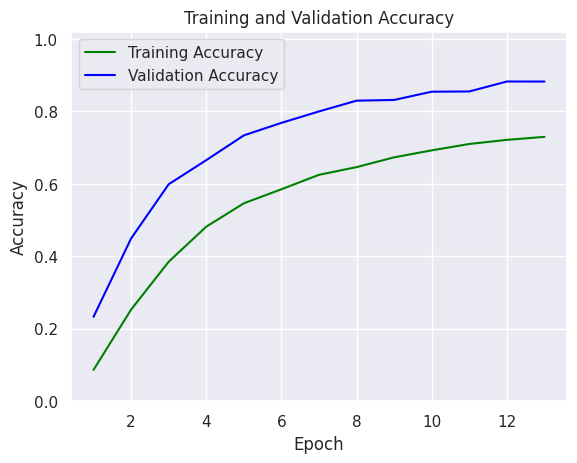

In [ ]:
plt.plot(epochs, acc, color='green', label='Training Accuracy')
plt.plot(epochs, val_acc, color='blue', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.ylim(0,1.02)
plt.show()

In [ ]:
model_evaluate = model.evaluate(test_generator)
print("Loss     : ",model_evaluate[0])
print("Accuracy : ",model_evaluate[1])
print("Precision  : ",model_evaluate[2])
print("Recall : ",model_evaluate[3])

138/138 ━━━━━━━━━━━━━━━━━━━━ 21s 149ms/step - accuracy: 0.8940 - loss: 0.3508 - precision: 0.9401 - recall: 0.8485
Loss     :  0.39113983511924744
Accuracy :  0.878339946269989
Precision  :  0.9331785440444946
Recall :  0.8225128054618835


In [ ]:
# EXPORTING PREDICTIONS FOR ANALYSIS

In [2]:
# import pandas as pd

# # Get predicted probabilities
# y_pred_proba = model.predict(test_generator)

# # Convert probabilities to class labels
# y_pred_labels = np.argmax(y_pred_proba, axis=1)

# # Get the corresponding class labels
# class_labels = list(test_generator.class_indices.keys())
# predicted_classes = [class_labels[i] for i in y_pred_labels]

# # Create a DataFrame with true labels, predicted labels, and probabilities
# df = pd.DataFrame({
#     'True Label': y_true,
#     'Predicted Label': predicted_classes,
#     'Predicted Probabilities': [probs.tolist() for probs in y_pred_proba]
# })

# # Save to a CSV file
# df.to_csv('predictions.csv', index=False)
# print("Predictions exported to 'predictions.csv'")


In [ ]:
print('accuracy',(history.history['accuracy'][-1])*100)

accuracy 72.96535968780518


In [ ]:
model.save('best_model.keras')

In [ ]:
# import tensorflow as tf
# print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))


# !nvidia-smi